# Stage 11 — Evaluation and Risk Communication

## 1. Goal

Compare modeling assumptions, bootstrap prediction error, and check whether one subgroup performs worse.

In [1]:
from pathlib import Path
import os
import sys

import ipynbname

try:
    HOMEWORK_DIR = Path(ipynbname.path()).resolve().parent
except (FileNotFoundError, IndexError):
    HOMEWORK_DIR = Path.cwd().resolve()
    candidate = HOMEWORK_DIR / "homework" / "homework11"
    if candidate.is_dir():
        HOMEWORK_DIR = candidate
os.chdir(HOMEWORK_DIR)
if str(HOMEWORK_DIR) not in sys.path:
    sys.path.insert(0, str(HOMEWORK_DIR))
print("Working from:", HOMEWORK_DIR.name)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

from src.evaluation import bootstrap_rmse, subgroup_rmse

RAW_DIR = HOMEWORK_DIR / 'data' / 'raw'
PROCESSED_DIR = HOMEWORK_DIR / 'data' / 'processed'
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

Working from: homework11


## 2. Data and baseline

Segment C is deliberately noisier, and the outcome contains a curved term. Missing predictor values make the imputation choice relevant.

In [2]:
sample_size = 600
x = rng.normal(size=sample_size)
segment = rng.choice(["A", "B", "C"], size=sample_size, p=[0.4, 0.4, 0.2])
segment_effect = pd.Series(segment).map({"A": 0.0, "B": 1.0, "C": -1.0}).to_numpy()
noise_scale = np.where(segment == "C", 2.0, 1.0)
y = 4 * x + 1.2 * x**2 + segment_effect + rng.normal(scale=noise_scale)
x[rng.random(sample_size) < 0.08] = np.nan
data = pd.DataFrame({"x": x, "segment": segment, "y": y})
data.to_csv(RAW_DIR / "data_stage11_eval_risk.csv", index=False)

train, test = train_test_split(
    data, test_size=0.25, random_state=RANDOM_SEED, stratify=data["segment"]
)

def build_model(imputation: str, degree: int) -> Pipeline:
    """Build a regression pipeline for one imputation and curvature assumption."""
    numeric = Pipeline([
        ("imputer", SimpleImputer(strategy=imputation)),
        ("polynomial", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
    ])
    preprocessing = ColumnTransformer([
        ("numeric", numeric, ["x"]),
        ("segment", OneHotEncoder(handle_unknown="ignore"), ["segment"]),
    ])
    return Pipeline([("preprocessing", preprocessing), ("model", LinearRegression())])

scenarios = {
    "mean + linear": build_model("mean", 1),
    "median + quadratic": build_model("median", 2),
}
predictions = {}
for name, model in scenarios.items():
    model.fit(train[["x", "segment"]], train["y"])
    predictions[name] = model.predict(test[["x", "segment"]])

## 3. Bootstrap uncertainty and scenarios

The model stays fixed while test rows are resampled 1,000 times. This measures test-sample uncertainty, not future regime change.

In [3]:
actual = test["y"].to_numpy()
scenario_rows = []
for name, predicted in predictions.items():
    lower, upper = bootstrap_rmse(actual, predicted, samples=1000, seed=RANDOM_SEED)
    scenario_rows.append({
        "scenario": name,
        "rmse": mean_squared_error(actual, predicted) ** 0.5,
        "mae": mean_absolute_error(actual, predicted),
        "ci_lower": lower,
        "ci_upper": upper,
    })
scenario_results = pd.DataFrame(scenario_rows).set_index("scenario")
scenario_results.to_csv(PROCESSED_DIR / "scenario_results.csv")
scenario_results

,rmse,mae,ci_lower,ci_upper
scenario,,,,
mean + linear,2.133517,1.673460,1.872886,2.371088
median + quadratic,1.477397,1.137372,1.267403,1.701496


## 4. Subgroup diagnostics and visuals

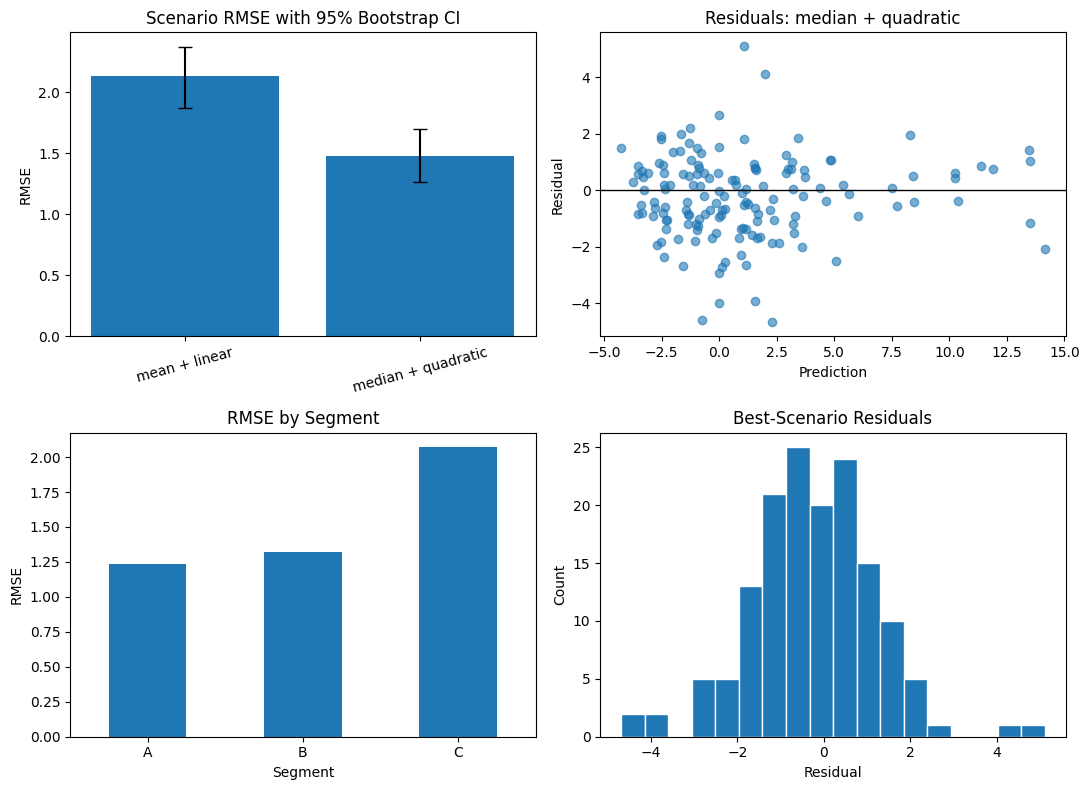

segment
A    1.233487
B    1.324466
C    2.070141
Name: rmse, dtype: float64

In [4]:
best_name = scenario_results["rmse"].idxmin()
best_predictions = predictions[best_name]
diagnostics = test[["segment", "y"]].copy()
diagnostics["prediction"] = best_predictions
diagnostics["residual"] = diagnostics["y"] - diagnostics["prediction"]
subgroup_results = subgroup_rmse(
    diagnostics,
    group_column="segment",
    actual_column="y",
    prediction_column="prediction",
)
subgroup_results.to_csv(PROCESSED_DIR / "subgroup_rmse.csv", header=["rmse"])

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
centers = scenario_results["rmse"]
errors = np.vstack([
    centers - scenario_results["ci_lower"],
    scenario_results["ci_upper"] - centers,
])
axes[0, 0].bar(centers.index, centers, yerr=errors, capsize=5)
axes[0, 0].set(title="Scenario RMSE with 95% Bootstrap CI", ylabel="RMSE")
axes[0, 0].tick_params(axis="x", rotation=15)

axes[0, 1].scatter(diagnostics["prediction"], diagnostics["residual"], alpha=0.6)
axes[0, 1].axhline(0, color="black", linewidth=1)
axes[0, 1].set(title=f"Residuals: {best_name}", xlabel="Prediction", ylabel="Residual")

subgroup_results.plot.bar(ax=axes[1, 0])
axes[1, 0].set(title="RMSE by Segment", xlabel="Segment", ylabel="RMSE")
axes[1, 0].tick_params(axis="x", rotation=0)

axes[1, 1].hist(diagnostics["residual"], bins=18, edgecolor="white")
axes[1, 1].set(title="Best-Scenario Residuals", xlabel="Residual", ylabel="Count")
fig.tight_layout()
plt.show()
subgroup_results.rename("rmse")

## 5. Stakeholder summary

The conclusion is sensitive to model form: allowing one curved term reduces error more than changing the missing-value fill alone. The bootstrap interval describes sampling uncertainty, but it assumes test rows can be resampled independently. Segment C remains the main risk because its errors are larger. I would use the result only while missingness and segment mix remain close to this sample, monitor Segment C separately, and collect more evidence before operational use.